In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

### Get File path and load the csv data

In [14]:
from util.data_path import cassava_path

In [15]:
wide = pd.read_csv(cassava_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [16]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

### Create a sequence dataset class for LSTM prediction

In [17]:
SEQ_LEN = 12
PRED_LEN = 12


class SeqDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]
        targ = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.from_numpy(seq).unsqueeze(-1), torch.from_numpy(targ)


In [18]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

### Create the LSTM regression model class

In [19]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden=32, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

### Training the LSTM model

In [20]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.01559
epoch 100/300  loss=0.00274
epoch 150/300  loss=0.00150
epoch 200/300  loss=0.00169
epoch 250/300  loss=0.00118
epoch 300/300  loss=0.00117


### Predict the data for the next year

In [21]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.51
2024-02-01    3.32
2024-03-01    3.20
2024-04-01    3.12
2024-05-01    3.06
2024-06-01    3.00
2024-07-01    2.94
2024-08-01    2.89
2024-09-01    2.84
2024-10-01    2.79
2024-11-01    2.75
2024-12-01    2.71
Freq: MS, Name: forecast_price, dtype: float64


In [22]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.51
2024-02-01    3.65            3.32
2024-03-01    3.57            3.20
2024-04-01    3.24            3.12
2024-05-01    3.19            3.06
2024-06-01    3.09            3.00
2024-07-01    3.06            2.94
2024-08-01    2.95            2.89
2024-09-01    2.86            2.84
2024-10-01    2.65            2.79
2024-11-01    2.60            2.75
2024-12-01    2.32            2.71


### Compare The Error of a predicted data and the actual data in a table format

In [23]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = error.abs()
pct_error = (error / cmp["actual"]) * 100


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "pct_error": pct_error,
    }
)
print(error_df.round(4))

average_percent_error = 0
for error_val in pct_error:
    average_percent_error += abs(error_val)

average_percent_error /= len(pct_error)
print(f"\n--- Average Percent Error: {average_percent_error:.2f}% ---")


--- Monthly Errors ---
            actual  forecast   error  abs_error  pct_error
2024-01-01    3.65    3.5075  0.1425     0.1425     3.9046
2024-02-01    3.65    3.3218  0.3282     0.3282     8.9917
2024-03-01    3.57    3.1976  0.3724     0.3724    10.4327
2024-04-01    3.24    3.1206  0.1194     0.1194     3.6850
2024-05-01    3.19    3.0595  0.1305     0.1305     4.0910
2024-06-01    3.09    3.0005  0.0895     0.0895     2.8954
2024-07-01    3.06    2.9430  0.1170     0.1170     3.8245
2024-08-01    2.95    2.8887  0.0613     0.0613     2.0765
2024-09-01    2.86    2.8389  0.0211     0.0211     0.7379
2024-10-01    2.65    2.7934 -0.1434     0.1434    -5.4120
2024-11-01    2.60    2.7520 -0.1520     0.1520    -5.8462
2024-12-01    2.32    2.7145 -0.3945     0.3945   -17.0060

--- Average Percent Error: 5.74% ---


### Plot The predicted data compare to an actual data

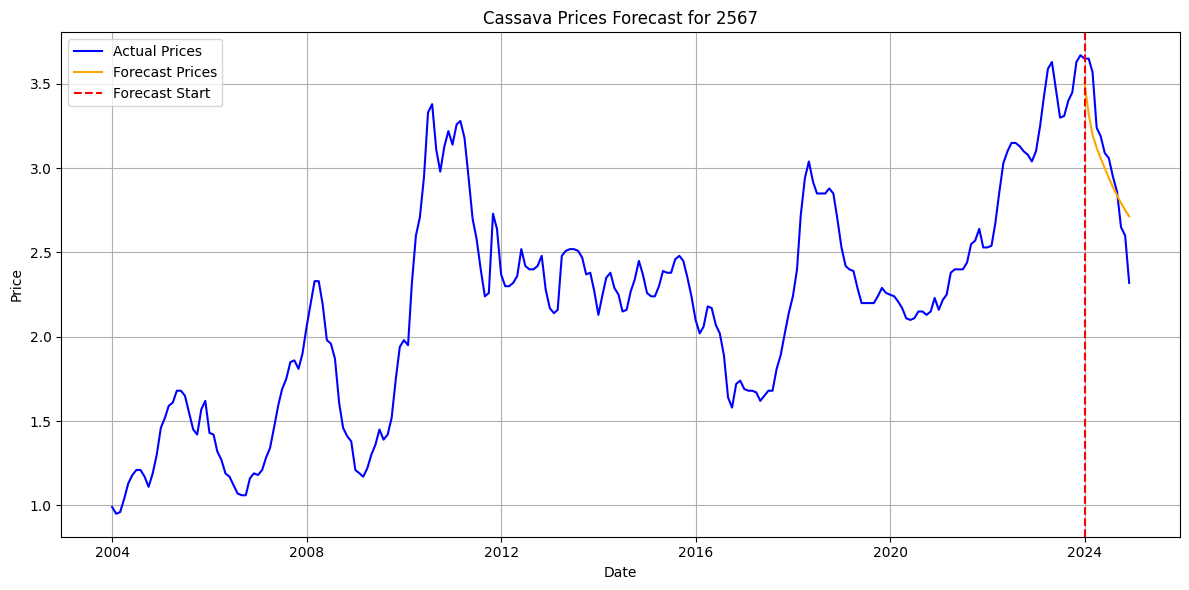

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()